In [4]:
import pandas as pd
import glob
import numpy as np
import re
import matplotlib.pyplot as plt

In [5]:
# data_dir = 'shots/'
data_dir = '../data/LHD_labeled_TCV/'

In [6]:
sig_all_names = glob.glob(data_dir + 'TCV_DATA*.parquet')
# use regex to get sample number:
sig_all = {int(re.findall(r'\d+', x)[0]): x for x in sig_all_names}
shot_no_list = list(sig_all.keys())


label_all = glob.glob(data_dir + 'TCV_*_apau_labeled.csv')
label_all = {int(x.split("TCV_")[1].split("_apau_labeled.csv")[0]): x for x in label_all}

In [7]:
print(f"All shots: {shot_no_list}")
print("Amount of shots: ", len(shot_no_list))
print(f"Labels: {len(label_all)}")

All shots: [30043, 64686, 71208, 61009, 63250, 61275, 57732, 63923, 30262, 61281, 32716, 33459, 64917, 61044, 64662, 63880, 64367, 42514, 64859, 60813, 77598, 34010, 48580, 61010, 61000, 59061, 69514, 61608, 73632, 75264, 61702, 32191, 61712, 57218, 65487, 64393, 73935, 64858, 77599, 60812, 64376, 26386, 64366, 43454, 53627, 57715, 57081, 63888, 61609, 61242, 69515, 68628, 63853, 63843, 73934, 64392, 58460, 75265, 64770, 52302, 61713, 61703, 65557, 65561, 61274, 68631, 77196, 56662, 77602, 53601, 61055, 57751, 64340, 64916, 53625, 64060, 42197, 57093, 30225, 64647, 64364, 64374, 30268, 30310, 73936, 67182, 61711, 31807, 57622, 73631, 57077, 64678, 32911, 65285, 45103, 65336, 64342, 61057, 64914, 69127, 68268, 64389, 63920, 65319, 60995, 61277, 64820, 64915, 63943, 31718, 63882, 58182, 64670, 29511, 65318, 73368, 61719, 33942, 63849, 33567, 57706, 63229, 31839, 61060, 33281, 64365, 64923, 64338, 73927, 59073, 57623, 75263, 57011, 61028, 68697, 61038, 67186, 59076, 74916, 59066, 64919, 6

In [16]:
# example
shotno =  shot_no_list[21]

sig = pd.read_parquet(sig_all[shotno])
label = pd.read_csv(label_all[shotno])
print(sig.columns.tolist())#[0:40]


['ShotNum', 'time', 'AREA', 'BETAN', 'BETAP', 'BOLO_z1', 'BOLO_z2', 'BOLO_z3', 'BOLO_z4', 'BOLO_z5', 'BOLO_z6', 'BOLO_z7', 'BOLO_z8', 'BOLO_z9', 'BOLO_z10', 'BOLO_z11', 'BOLO_z12', 'BOLO_z13', 'BOLO_z14', 'BOLO_z15', 'BOLO_z16', 'BOLO_z17', 'BOLO_z18', 'BOLO_z19', 'BOLO_z20', 'BOLO_z21', 'BOLO_z22', 'BOLO_z23', 'BOLO_z24', 'BOLO_z25', 'BOLO_z26', 'BOLO_z27', 'BOLO_z28', 'BOLO_z29', 'BOLO_z30', 'BOLO_z31', 'BOLO_z32', 'BOLO_z33', 'BOLO_z34', 'BOLO_z35', 'BOLO_z36', 'BOLO_z37', 'BOLO_z38', 'BOLO_z39', 'BOLO_z40', 'BOLO_z41', 'BOLO_z42', 'BOLO_z43', 'BOLO_z44', 'BOLO_z45', 'BOLO_z46', 'BOLO_z47', 'BOLO_z48', 'BOLO_z49', 'BOLO_z50', 'BOLO_z51', 'BOLO_z52', 'BOLO_z53', 'BOLO_z54', 'BOLO_z55', 'BOLO_z56', 'BOLO_z57', 'BOLO_z58', 'BOLO_z59', 'BOLO_z60', 'BOLO_z61', 'BOLO_z62', 'BOLO_z63', 'BOLO_z64', 'BZERO', 'DELTA', 'DML', 'ECRH', 'EvenN', 'FIR_core', 'FIR_LADs_z1', 'FIR_LADs_z2', 'FIR_LADs_z3', 'FIR_LADs_z4', 'FIR_LADs_z5', 'FIR_LADs_z6', 'FIR_LADs_z7', 'FIR_LADs_z8', 'FIR_LADs_z9', 'FIR_L

In [63]:
'FIR_core' in sig.columns.tolist()

True

In [64]:
sig

,ShotNum,time,AREA,AXUV_z1,AXUV_z2,AXUV_z3,AXUV_z4,AXUV_z5,AXUV_z6,AXUV_z7,...,VOL,WP,Z_axis,a_minor,gas_actual_ampl,gas_fringes,gas_ref,powers_calc,PD_fft_4ms,PD_fft_80ms
0,64913.0,0.0142,0.151298,627270.125000,647104.687500,725462.062500,529149.18750,606652.250000,618523.000,1.111819e+06,...,0.797285,0.000000,-0.002492,0.214779,3.364258,0.523941,0.0,129433.515625,0.042906,0.006877
1,64913.0,0.0143,0.151298,100293.171875,197121.218750,231425.796875,247580.90625,284885.906250,410815.125,1.021873e+06,...,0.797285,0.000000,-0.002492,0.214779,3.364258,0.527397,0.0,129433.515625,0.040158,0.006919
2,64913.0,0.0144,0.151298,551987.187500,582821.187500,615676.375000,716861.81250,526210.312500,722376.750,1.321692e+06,...,0.797285,0.000000,-0.002492,0.214779,3.364258,0.522156,0.0,129433.515625,0.037786,0.006954
3,64913.0,0.0145,0.151298,175575.562500,197121.218750,286318.562500,247580.90625,244665.234375,549287.000,1.141801e+06,...,0.797285,0.000000,-0.002492,0.214779,3.364258,0.517261,0.0,129433.515625,0.035296,0.007003
4,64913.0,0.0146,0.151298,175575.562500,197121.218750,286318.562500,247580.90625,244665.234375,549287.000,1.141801e+06,...,0.797285,0.000000,-0.002492,0.214779,3.364258,0.524123,0.0,129433.515625,0.033043,0.007056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3732,64913.0,0.3874,0.219980,100293.171875,132837.984375,231425.796875,341436.90625,325106.750000,410815.125,3.322906e+05,...,1.143185,2220.105713,0.073907,0.213989,3.242188,0.625737,1.6,95216.562500,0.109117,0.017002
3733,64913.0,0.3875,0.219980,100293.171875,197121.218750,66746.867188,576077.25000,365327.625000,618523.000,3.322906e+05,...,1.143185,2220.105713,0.073907,0.213989,3.242188,0.691082,1.6,95216.562500,0.080433,0.017075
3734,64913.0,0.3876,0.219980,100293.171875,197121.218750,66746.867188,576077.25000,365327.625000,618523.000,3.322906e+05,...,1.143185,2220.105713,0.073907,0.213989,3.242188,0.525428,1.6,95216.562500,0.077230,0.017164
3735,64913.0,0.3877,0.219980,627270.125000,647104.687500,231425.796875,669933.75000,445768.906250,687758.875,3.922542e+05,...,1.143185,2220.105713,0.073907,0.213989,3.242188,0.315922,1.6,95216.562500,0.078237,0.017211


In [17]:
sig['time'].describe()
time_diff = sig['time'].diff()
frequency = 1 / time_diff.mean()
is_consistent = time_diff.std() < 1e-7
inconsistent_steps = ~np.isclose(time_diff, time_diff.mean(), atol=1e-7, equal_nan=True)
print(f"Frequency: {frequency}, is broadly consistent: {is_consistent}")

print(f"{inconsistent_steps.sum()} steps out of {len(inconsistent_steps)} were not exaclty the same as the mean step size.")

# dilate the mask by one step
inconsistent_steps = inconsistent_steps | np.roll(inconsistent_steps,1)
print(time_diff[inconsistent_steps])
time_diff.describe()


Frequency: 10000.000252621256, is broadly consistent: True
1 steps out of 4084 were not exaclty the same as the mean step size.
0       NaN
1    0.0001
Name: time, dtype: float32


count    4.083000e+03
mean     1.000000e-04
std      1.009589e-08
min      9.998679e-05
25%      9.998679e-05
50%      1.000017e-04
75%      1.000017e-04
max      1.000166e-04
Name: time, dtype: float64

In [8]:
def check_time_consistency(signal_df):
    time_diff = signal_df['time'].diff()
    time_start = signal_df['time'].iloc[0]
    time_end = signal_df['time'].iloc[-1]
    length = len(signal_df)
    frequency = 1 / time_diff.mean()
    is_consistent = time_diff.std() < 1e-7
    inconsistent_steps = ~np.isclose(time_diff, time_diff.mean(), atol=1e-7, equal_nan=True)
    # print(f"Frequency: {frequency}, is broadly consistent: {is_consistent}")
    # print(f"{inconsistent_steps.sum()} steps out of {len(inconsistent_steps)} were not exaclty the same as the mean step size.")
    return is_consistent, inconsistent_steps.sum(), frequency, time_start, time_end, length

In [9]:
shot_keys = list(sig_all.keys())
# plt.suptitle("FIR response with red-marked H-mode for 10 shots")
lengths = []
starts = []
for i, shotno in enumerate(shot_keys[0:100]):
    sig = pd.read_parquet(sig_all[shotno])
    label = pd.read_csv(label_all[shotno])
    is_consistent, inconsistent_steps, frequency, time_start, time_end, length = check_time_consistency(sig)
    print(f"Shot: {shotno}, consistent: {is_consistent}, inconsistent steps: {inconsistent_steps}, frequency: {frequency}, time_start: {time_start}, time_end: {time_end}, length: {length}")
    lengths.append(length)
    starts.append(time_start)



Shot: 30043, consistent: True, inconsistent steps: 1233, frequency: 10000.000252621256, time_start: 0.018300000578165054, time_end: 1.8847999572753906, length: 18666
Shot: 64686, consistent: True, inconsistent steps: 1005, frequency: 9999.999525025509, time_start: 0.015699999406933784, time_end: 1.7213000059127808, length: 17057
Shot: 71208, consistent: True, inconsistent steps: 550, frequency: 9999.999525025509, time_start: 0.016200000420212746, time_end: 1.3941999673843384, length: 13781
Shot: 61009, consistent: True, inconsistent steps: 1388, frequency: 10000.000252621256, time_start: 0.013199999928474426, time_end: 1.9961999654769897, length: 19831
Shot: 63250, consistent: True, inconsistent steps: 831, frequency: 9999.999525025509, time_start: 0.01360000018030405, time_end: 1.596500039100647, length: 15830
Shot: 61275, consistent: True, inconsistent steps: 857, frequency: 10000.000252621256, time_start: 0.01759999990463257, time_end: 1.6150000095367432, length: 15975
Shot: 57732, 

Mean length: 14869.69
Median length: 15551.0
Mode length: 4084
Standard deviation: 4383.057774419589
1st quartile: 11937.75
3rd quartile: 18222.0
Shortest 20 signals: [21 31 78 87 10 44 80 88 53 72 14 42 35  7 83 16 40 36 47 74]


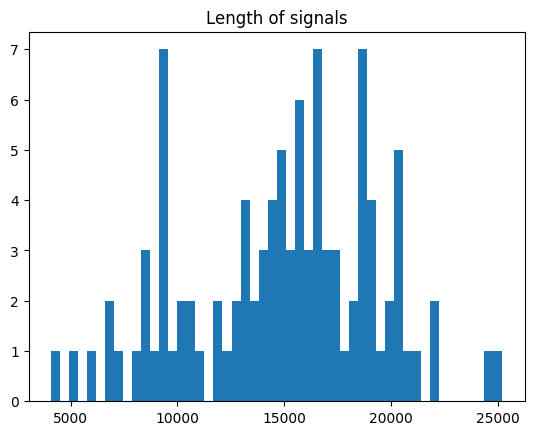

In [15]:
lengths_array = np.array(lengths)
plt.hist(lengths_array, bins=50)
plt.title("Length of signals")
lengths_array = np.array(lengths)

mean_length = np.mean(lengths_array)
median_length = np.median(lengths_array)
mode_length = np.argmax(np.bincount(lengths_array))
std_length = np.std(lengths_array)
q1_length = np.percentile(lengths_array, 25)
q3_length = np.percentile(lengths_array, 75)


print(f"Mean length: {mean_length}")
print(f"Median length: {median_length}")
print(f"Mode length: {mode_length}")
print(f"Standard deviation: {std_length}")
print(f"1st quartile: {q1_length}")
print(f"3rd quartile: {q3_length}")

least_k = 20
shortest_k = np.argsort(lengths_array)[:least_k]
print(f"Shortest {least_k} signals: {shortest_k}")



In [20]:
cols_control = [
    "IP",  # Current (niet reference lijn voor controller, maar de ware input. Dan laat je control bij control)
    "gas_fringes",  # Ingepompte gas
    "NBI",  # manieren om te verhitten: colliding Neutral beam injection
    "ECRH",  # magnetron.
    "a_minor",  # reel gemeten plasma shape a k d (horizontale radius
    "KAPPA",
    "DELTA"  # inkerbovenhoek nar links vanuit hetmidden
]
cols_data = [  
    # "FIR",  # density lijn Interferometer
    "FIR_core",  # For the March dataset of 260 shots, the FIR_core signal is the same as FIR.
    "PD",  # photodiode lijn op de divertor
    "DML",  # Magnetische respons  correleert met de energie in het plasma
    "POHM",  # Gemeten power waarde meet de power die uit wrijving komt
    "Z_axis"  # center Plasma positie in de verticale lijn. deviation van reference is betekenis. 
]
all_cols = cols_control + cols_data
assert all([x in sig.columns for x in all_cols
            ]), f"Missing columns {set(all_cols) - set(sig.columns)}"

```

cols_label = ["LHD_label"]

For the labels, 0 = no label, 1 = low confinement mode, 2 = dithering ('inbetween'), 3 = high confinement mode

This is data for full shots (shot = pulse = experiment). We do not want to model the full shot, but rather an area just around a transition in the LHD_label, so zooming in on say ~100ms before/after a transition in the LHD_label
```

In [21]:
sig

,ShotNum,time,AREA,BETAN,BETAP,BOLO_z1,BOLO_z2,BOLO_z3,BOLO_z4,BOLO_z5,...,VOL,WP,Z_axis,a_minor,gas_actual_ampl,gas_fringes,gas_ref,powers_calc,PD_fft_4ms,PD_fft_80ms
0,34010.0,0.0155,0.170228,0.271790,0.990357,9419.959961,9674.861328,12176.716797,11404.111328,12196.020508,...,0.907460,259.727203,0.017341,0.223971,3.183592,0.516544,0.0,322911.0000,0.142198,0.029141
1,34010.0,0.0156,0.170228,0.271790,0.990357,9302.661133,9616.750977,11820.540039,11146.396484,12165.748047,...,0.907460,259.727203,0.017341,0.223971,3.183592,0.519121,0.0,322911.0000,0.141265,0.029245
2,34010.0,0.0157,0.170228,0.271790,0.990357,9302.661133,9616.750977,11820.540039,11146.396484,12165.748047,...,0.907460,259.727203,0.017341,0.223971,3.183592,0.525493,0.0,322911.0000,0.140671,0.029331
3,34010.0,0.0158,0.170228,0.271790,0.990357,9302.661133,9616.750977,11820.540039,11146.396484,12165.748047,...,0.907460,259.727203,0.017341,0.223971,3.183592,0.525488,0.0,322911.0000,0.139438,0.029399
4,34010.0,0.0159,0.170228,0.271790,0.990357,9302.661133,9616.750977,11820.540039,11146.396484,12165.748047,...,0.907460,259.727203,0.017341,0.223971,3.183592,0.533294,0.0,322911.0000,0.137015,0.029462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4079,34010.0,0.4234,0.234239,1.026316,0.347354,170676.687500,208751.031250,243842.031250,289213.562500,570484.312500,...,1.254864,16693.576172,0.020444,0.215188,1.787109,2.590461,3.5,542814.0625,0.143603,0.059996
4080,34010.0,0.4235,0.234239,1.026316,0.347354,170676.687500,208751.031250,243842.031250,289213.562500,570484.312500,...,1.254864,16693.576172,0.020444,0.215188,1.787109,2.872847,3.5,542814.0625,0.145048,0.060364
4081,34010.0,0.4236,0.234239,1.026316,0.347354,164328.312500,201486.390625,235774.531250,279951.000000,555260.625000,...,1.254864,16693.576172,0.020444,0.215188,1.787109,2.321896,3.5,542814.0625,0.146103,0.060722
4082,34010.0,0.4237,0.234239,1.026316,0.347354,164328.312500,201486.390625,235774.531250,279951.000000,555260.625000,...,1.254864,16693.576172,0.020444,0.215188,1.787109,2.117173,3.5,542814.0625,0.146473,0.061080


In [22]:
# normalize data
raw_sig = sig.copy()
sig[all_cols] = (sig[all_cols] - sig[all_cols].mean()) / sig[all_cols].std()

In [68]:
label

,time,IP,SXR,FIR,PD,WP,P_LHfr_RT,LHD_label,ELM_label,ST_MD_label1,ST_MD_label2
0,0.0166,-50176.434125,0.529197,7.102158e+18,3.100527,-0.000069,0.917529,1,0,0,0
1,0.0167,-50970.359796,0.529197,7.108519e+18,3.127383,-0.000075,0.917529,1,0,0,0
2,0.0168,-51824.050844,0.530072,7.163398e+18,3.173769,-0.000085,0.917529,1,0,0,0
3,0.0169,-52690.416374,0.530345,7.197152e+18,3.166327,-0.000079,0.917529,1,0,0,0
4,0.0170,-53458.050903,0.529641,7.150677e+18,3.124941,-0.000060,0.917529,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
3701,0.3867,-60574.048484,0.528774,1.306983e+19,3.398665,-0.000141,0.395025,1,0,0,0
3702,0.3868,-58514.253049,0.526806,1.377941e+19,3.540133,-0.000138,0.395025,1,0,0,0
3703,0.3869,-56522.933888,0.523221,1.307154e+19,3.542426,-0.000144,0.395025,1,0,0,0
3704,0.3870,-54336.521611,0.528146,1.264659e+19,3.462039,-0.000142,0.395025,1,0,0,0


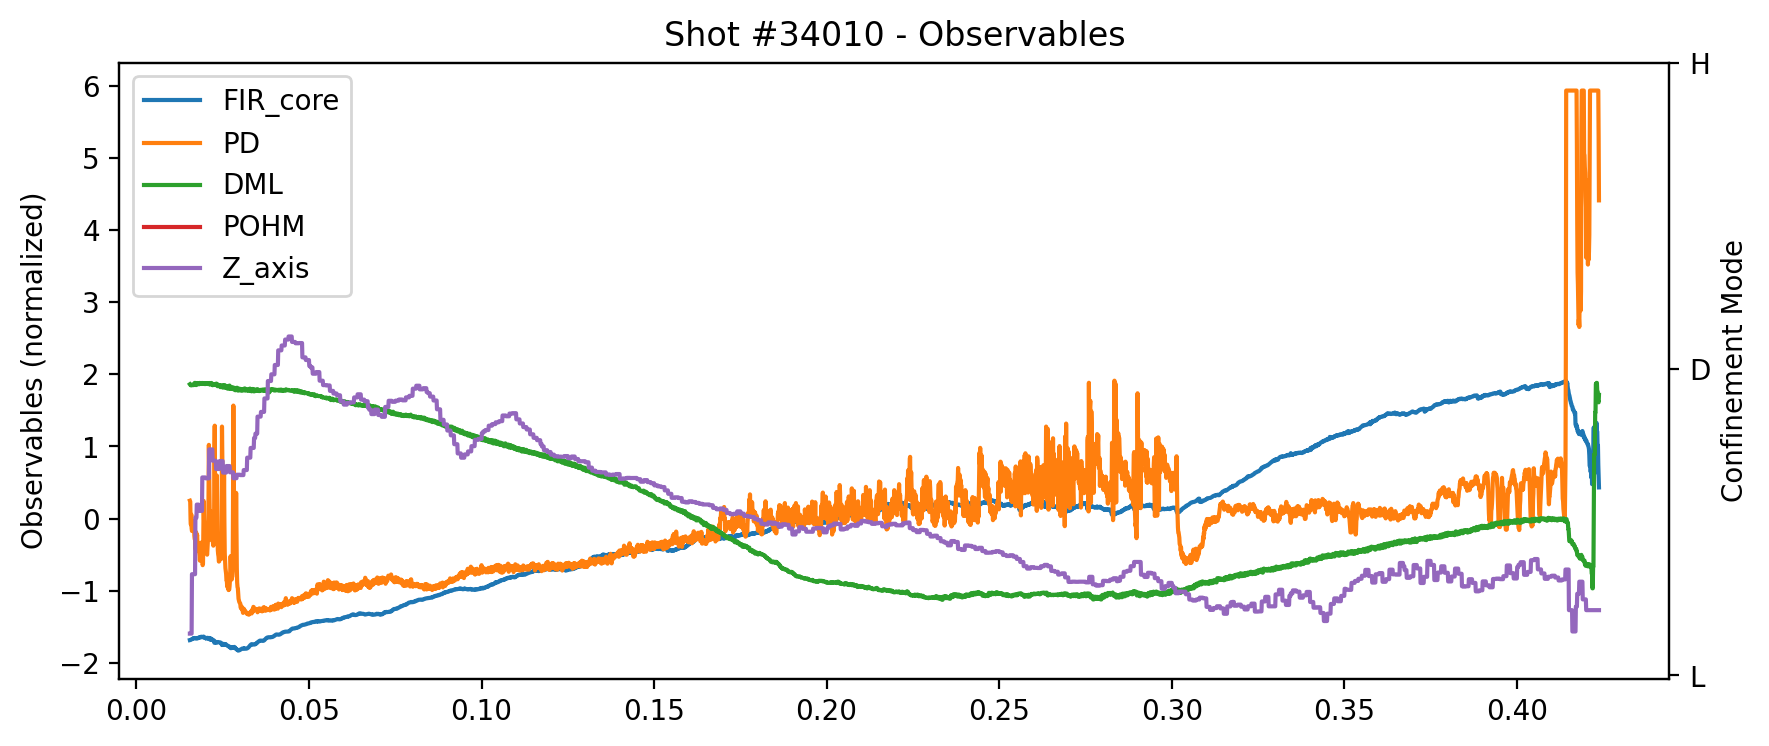

In [24]:
# Plot observables
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
plt.title(f"Shot #{shotno} - Observables")
ax.set_ylabel("Observables (normalized)")
ax.plot(sig["time"], sig[cols_data], )
# ax.set_ylim([-3, 5.3])
# ax.set_xlim([0.6, 0.8])


ax2 = ax.twinx()

# interpolate missing labels (label==0) to previous
labelvals = np.array(label["LHD_label"])
mask = labelvals == 0
labelvals[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), labelvals[~mask])
# plot filled area:
# ax2.fill_between(label["time"], labelvals, color='red', alpha=.2, )
# ax2.plot(label["time"], labelvals, color='red', alpha=.3, )
# set axis limits:
ax2.set_ylim([0.99, 3])
ax2.set_ylabel("Confinement Mode")

# Change y-axis tick positions
ax2.set_yticks([1, 2, 3])
# Change y-axis tick labels
ax2.set_yticklabels(['L', 'D', 'H'])
legend = ax.legend(cols_data, loc='upper left')
plt.show()


NameError: name 'cols_control' is not defined

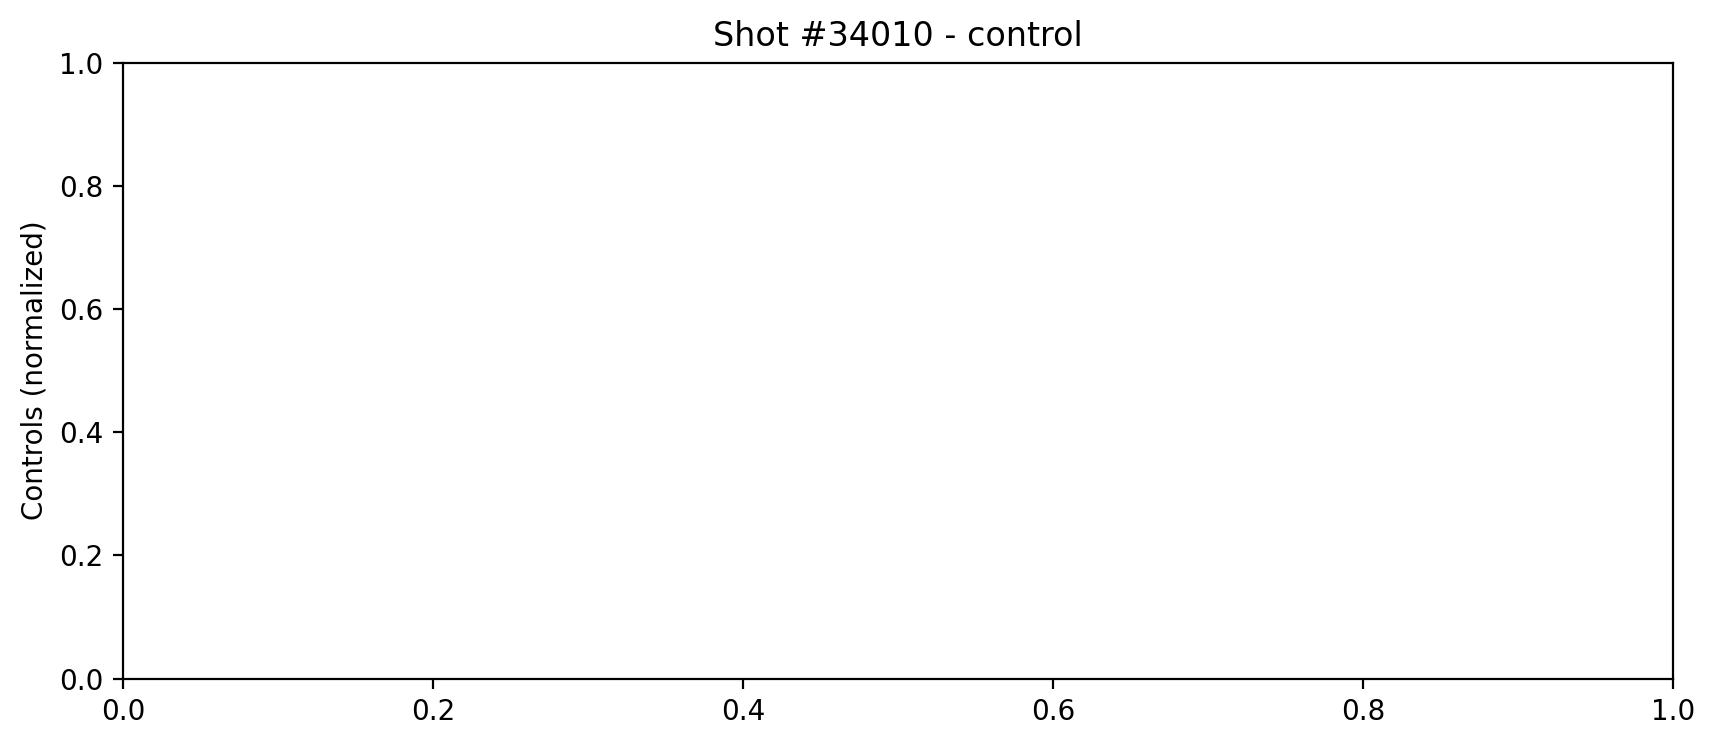

In [19]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=200)
plt.title(f"Shot #{shotno} - control")

ax.set_ylabel("Controls (normalized)")

ax.plot(sig["time"], sig[cols_control])
ax.set_ylim([-2, 1.5])

ax2 = ax.twinx()

# interpolate missing labels (label==0) to previous
labelvals = np.array(label["LHD_label"])
mask = labelvals == 0
labelvals[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), labelvals[~mask])
# plot filled area:
# ax2.fill_between(label["time"], labelvals, color='red', alpha=.2)
ax2.set_ylim([.99, 3])
ax2.set_ylabel("Confinement Mode")
# ax2.set_xlim([0.6, 0.8])
# ax2.set_xlim([sig["time"].min(), sig["time"].max()])

# Change y-axis tick positions
ax2.set_yticks([1, 2, 3])
# Change y-axis tick labels
ax2.set_yticklabels(['L', 'D', 'H'])

legend = ax.legend(cols_control, loc='best')

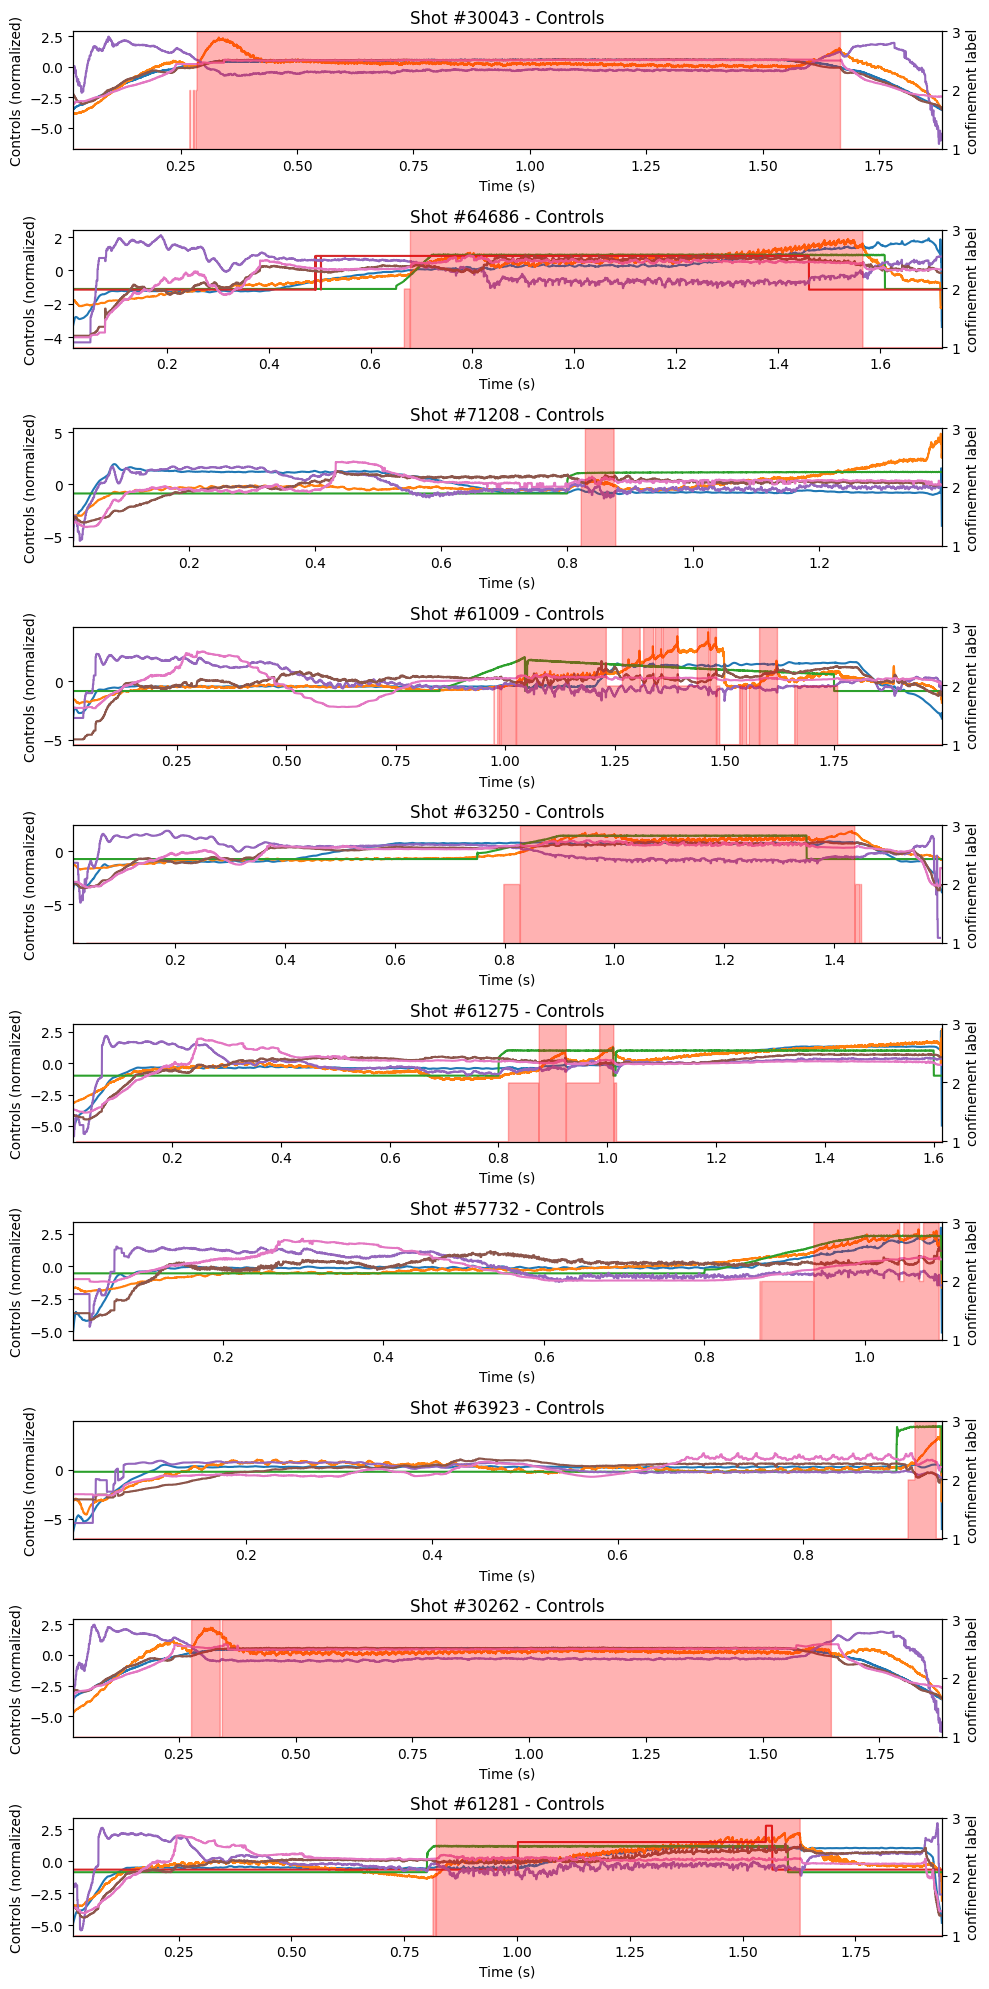

In [27]:
fig, axs = plt.subplots(10, 1, figsize=(10, 20))

shot_keys = list(sig_all.keys())
# plt.suptitle("FIR response with red-marked H-mode for 10 shots")

for i, shotno in enumerate(shot_keys[0:10]):
    sig = pd.read_parquet(sig_all[shotno])
    label = pd.read_csv(label_all[shotno])
    sig[all_cols] = (sig[all_cols] - sig[all_cols].mean()) / sig[all_cols].std()
    is_dithering = label["LHD_label"] == 2
    
    axs2 = axs[i].twinx()
    axs2.fill_between(label["time"], label["LHD_label"], color='red', alpha=.3)
    ax2.plot(label.loc[is_dithering,"time"], label.loc[is_dithering,"LHD_label"], color='purple', alpha=.3, )
    axs[i].plot(sig["time"], sig[cols_control])
    # axs[i].set_ylabel("Observables (normalized)")
    axs[i].set_ylabel("Controls (normalized)")
    
    plt.title(f"Shot #{shotno} - Controls")
    # plt.title(f"Shot #{shotno} - Observables")
    # ax.set_ylim([-3, 5.3])
    # ax.set_xlim([0.6, 0.8])
    
    axs2.set_ylim([0.99, 3])
    axs2.set_ylabel("confinement label")
    
    # Set x-axis limits
    axs[i].set_xlim([sig["time"].min(), sig["time"].max()])
    
    # Add time label to x-axis
    axs[i].set_xlabel("Time (s)")

    
plt.tight_layout()
plt.savefig('10shots.pdf')  

plt.show()
